# 06 — Frozen final models and held-out test evaluation

Reconstructs the frozen LT, Poisson and XGBoost models, loads the frozen
ConvLSTM predictions, and reproduces the final 2023–2025 test comparison.

No model selection or tuning is performed in this notebook.

## Recovered final specifications

From the source modelling notebook:

- **LT:** `epsilon = 0.10`; validation log score approximately `-0.0399535`.
- **Poisson:** fixed LT offset + `log1p(X1)` + `log1p(X7)`. This specification outperformed the corresponding LT-predictor formulation on validation data.
- **XGBoost:** `log_LT`, `X1`, `X7`, `X21`, `X30`; `max_depth=4`, `min_child_weight=1`, `subsample=0.85`, `colsample_bytree=0.85`, `reg_lambda=0.25`, `reg_alpha=0`, `eta=0.08`, seed `2026`, **103 trees**. Validation log score approximately `-0.03598925`.

No model selection is performed in this notebook.


In [16]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from scipy.special import gammaln
from sklearn.linear_model import PoissonRegressor
import joblib
import xgboost as xgb   

pd.set_option("display.max_columns", 100)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"
PRED_DIR = OUTPUT_DIR / "predictions"
AUDIT_DIR = OUTPUT_DIR / "audit"

for _d in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, PRED_DIR, AUDIT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

GRID_MASK_FILE = DATA_DIR / "california_grid_centre_mask.csv"
FINAL_CATALOGUE_FILE = DATA_DIR / "earthquake_california_grid_2010_2025_Mw25_centre_mask.csv"

# Produced by the separate ConvLSTM notebook.
CONVLSTM_PRED_FILE = PRED_DIR / "final_convlstm_test_predictions.npz"

print("Working directory:", DATA_DIR.resolve())
print("XGBoost version:", xgb.__version__)


Working directory: E:\test\california_earthquake_forecasting_reproducible\data
XGBoost version: 3.4.1


## 1. Load the fixed modelling data

This notebook starts from the already harmonised final catalogue. It does **not** repeat the USGS download or magnitude-harmonisation workflow.


In [17]:
for required in [GRID_MASK_FILE, FINAL_CATALOGUE_FILE]:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing {required.name}. Put it in the same folder as this notebook."
        )

grid_mask = pd.read_csv(GRID_MASK_FILE)
df = pd.read_csv(FINAL_CATALOGUE_FILE)

# Fixed cell order used throughout all model comparisons.
cell_ids = np.sort(grid_mask["cell_id"].astype(int).unique())

assert len(cell_ids) == 1080
assert grid_mask["cell_id"].is_unique

df["time"] = pd.to_datetime(
    df["time"],
    format="mixed",
    utc=True,
    errors="raise"
)
df["date"] = df["time"].dt.floor("D").dt.tz_localize(None)

print("Final catalogue events:", len(df))
print("Retained cells:", len(cell_ids))
print("Catalogue date range:", df["date"].min(), "to", df["date"].max())

assert len(df) == 30347


Final catalogue events: 30347
Retained cells: 1080
Catalogue date range: 2010-01-01 00:00:00 to 2025-12-31 00:00:00


## 2. Rebuild the common daily counts, target and temporal splits

All models use the same day-cell target and the same chronological train/validation/test periods.


In [18]:
START_DATE = "2010-01-01"
END_DATE = "2025-12-31"
TARGET_MAG = 3.0
FORECAST_HORIZON = 7

dates = pd.date_range(START_DATE, END_DATE, freq="D")

# Daily Mw* >= 2.5 counts used as recent-seismicity predictors.
daily_counts_25 = (
    df.groupby(["date", "cell_id"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=dates, columns=cell_ids, fill_value=0)
)

def build_daily_count_matrix(data, threshold, dates, cell_ids):
    temp = data.loc[data["mag_Mw"] >= threshold].copy()
    return (
        temp.groupby(["date", "cell_id"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=dates, columns=cell_ids, fill_value=0)
    )

def future_target_matrix(daily_counts, horizon):
    # Y_t = sum of counts on t+1,...,t+horizon.
    return (
        daily_counts.iloc[::-1]
        .rolling(window=horizon, min_periods=horizon)
        .sum()
        .shift(1)
        .iloc[::-1]
    )

daily_counts_target = build_daily_count_matrix(
    df, TARGET_MAG, dates, cell_ids
)

Y_7 = future_target_matrix(
    daily_counts_target,
    FORECAST_HORIZON
)

# Recent windows needed by the final models.
X_1 = daily_counts_25.rolling(1, min_periods=1).sum()
X_7 = daily_counts_25.rolling(7, min_periods=7).sum()
X_21 = daily_counts_25.rolling(21, min_periods=21).sum()
X_30 = daily_counts_25.rolling(30, min_periods=30).sum()

eligible = X_30.notna().all(axis=1) & Y_7.notna().all(axis=1)
forecast_dates = dates[eligible]

train_dates = forecast_dates[
    (forecast_dates >= "2010-01-30") &
    (forecast_dates <= "2019-12-24")
]
val_dates = forecast_dates[
    (forecast_dates >= "2020-01-01") &
    (forecast_dates <= "2022-12-24")
]
test_dates = forecast_dates[
    (forecast_dates >= "2023-01-01") &
    (forecast_dates <= "2025-12-24")
]

print("Daily input events:", int(daily_counts_25.to_numpy().sum()))
print("Target Mw* >= 3.0 events:", int(daily_counts_target.to_numpy().sum()))
print("Eligible origins:", len(forecast_dates))
print("Train / validation / test:", len(train_dates), len(val_dates), len(test_dates))

assert daily_counts_25.to_numpy().sum() == 30347
assert daily_counts_target.to_numpy().sum() == 6586
assert len(forecast_dates) == 5808
assert len(train_dates) == 3616
assert len(val_dates) == 1089
assert len(test_dates) == 1089


Daily input events: 30347
Target Mw* >= 3.0 events: 6586
Eligible origins: 5808
Train / validation / test: 3616 1089 1089


In [19]:
def poisson_log_score(y, lam):
    y = np.asarray(y, dtype=np.float64)
    lam = np.asarray(lam, dtype=np.float64)

    if np.any(lam <= 0):
        raise ValueError("All Poisson means must be positive.")

    return np.mean(
        y * np.log(lam)
        - lam
        - gammaln(y + 1.0)
    )

def flatten_target(origin_dates):
    return (
        Y_7.loc[origin_dates]
        .to_numpy(dtype=np.float64)
        .reshape(-1)
    )

y_train = flatten_target(train_dates)
y_val = flatten_target(val_dates)
y_test = flatten_target(test_dates)

Y_test_matrix = Y_7.loc[test_dates].to_numpy(dtype=np.float64)

print("Test matrix shape:", Y_test_matrix.shape)
print("Observed mean statewide 7-day count:", Y_test_matrix.sum(axis=1).mean())


Test matrix shape: (1089, 1080)
Observed mean statewide 7-day count: 5.235078053259872


## 3. Final Long-Term Spatial Rate model

The final LT benchmark uses the training-calendar target counts from 2010-01-01 to 2019-12-31 and the already selected uniform-mixture smoothing value `epsilon = 0.10`.


In [20]:
LT_TRAIN_START = pd.Timestamp("2010-01-01")
LT_TRAIN_END = pd.Timestamp("2019-12-31")
EPSILON_LT = 0.10

train_daily_target = daily_counts_target.loc[
    LT_TRAIN_START:LT_TRAIN_END
]

n_train_days = len(train_daily_target)
N_g = train_daily_target.sum(axis=0).astype(float)
N_total = float(N_g.sum())
G = len(cell_ids)

p_empirical = N_g / N_total
weekly_total_rate = FORECAST_HORIZON * N_total / n_train_days

p_smoothed = (
    (1.0 - EPSILON_LT) * p_empirical
    + EPSILON_LT / G
)

lambda_LT_final = (
    weekly_total_rate * p_smoothed
).astype(float)

LT_val_matrix = np.broadcast_to(
    lambda_LT_final.to_numpy()[None, :],
    (len(val_dates), G)
).copy()

LT_test_matrix = np.broadcast_to(
    lambda_LT_final.to_numpy()[None, :],
    (len(test_dates), G)
).copy()

LT_validation_log_score = poisson_log_score(
    Y_7.loc[val_dates].to_numpy(),
    LT_val_matrix
)
LT_test_log_score = poisson_log_score(
    Y_test_matrix,
    LT_test_matrix
)

print("Training calendar days:", n_train_days)
print("Training target events:", int(N_total))
print("Final epsilon:", EPSILON_LT)
print("California-wide 7-day LT forecast:", lambda_LT_final.sum())
print("Validation log score:", LT_validation_log_score)
print("Test log score:", LT_test_log_score)

assert n_train_days == 3652
assert int(N_total) == 4565
assert np.isclose(lambda_LT_final.sum(), 8.75)
assert np.isclose(
    LT_validation_log_score,
    -0.03995350752315059,
    atol=1e-12
)


Training calendar days: 3652
Training target events: 4565
Final epsilon: 0.1
California-wide 7-day LT forecast: 8.75
Validation log score: -0.03995350752315063
Test log score: -0.029728642850436967


## 4. Final Poisson regression

Recovered final specification:

\[
\log \lambda^{P}_{t,g}
=
\log \hat\lambda^{LT}_{g}
+ \beta_0
+ \beta_1\log(1+X^{(1)}_{t,g})
+ \beta_7\log(1+X^{(7)}_{t,g}).
\]

`scikit-learn` does not expose a native offset argument in `PoissonRegressor`. The source notebook implemented the fixed LT offset by fitting `y / LT` with sample weights equal to `LT`, which is likelihood-equivalent for this Poisson model. The model is fitted on the training period only.


In [21]:
def build_poisson_features(origin_dates):
    x1 = X_1.loc[origin_dates].to_numpy(dtype=float).reshape(-1)
    x7 = X_7.loc[origin_dates].to_numpy(dtype=float).reshape(-1)
    return np.column_stack([
        np.log1p(x1),
        np.log1p(x7)
    ])

def repeat_LT(origin_dates):
    return np.tile(
        lambda_LT_final.to_numpy(dtype=float),
        len(origin_dates)
    )

X_train_P = build_poisson_features(train_dates)
X_val_P = build_poisson_features(val_dates)
X_test_P = build_poisson_features(test_dates)

LT_train = repeat_LT(train_dates)
LT_val = repeat_LT(val_dates)
LT_test = repeat_LT(test_dates)

final_poisson = PoissonRegressor(
    alpha=0.0,
    fit_intercept=True,
    max_iter=2000,
    tol=1e-9
)

final_poisson.fit(
    X_train_P,
    y_train / LT_train,
    sample_weight=LT_train
)

poisson_val_pred = (
    LT_val * final_poisson.predict(X_val_P)
)
poisson_test_pred = (
    LT_test * final_poisson.predict(X_test_P)
)

poisson_validation_log_score = poisson_log_score(
    y_val,
    poisson_val_pred
)
poisson_test_log_score = poisson_log_score(
    y_test,
    poisson_test_pred
)

poisson_test_matrix = poisson_test_pred.reshape(
    len(test_dates), G
)

print("Intercept:", final_poisson.intercept_)
print("beta_1:", final_poisson.coef_[0])
print("beta_7:", final_poisson.coef_[1])
print("Iterations:", final_poisson.n_iter_)
print("Validation log score:", poisson_validation_log_score)
print("Test log score:", poisson_test_log_score)

# The source notebook reported approximately -0.038939.
assert np.isclose(
    poisson_validation_log_score,
    -0.038939,
    atol=5e-7
)


Intercept: -0.21350447377329873
beta_1: 0.5304267361135772
beta_7: 0.34440688973748257
Iterations: 13
Validation log score: -0.038939111824337645
Test log score: -0.028978064731442772


## 5. Final XGBoost model

Recovered final specification:

- LT enters as an **ordinary `log_LT` feature**.
- Recent seismicity uses raw count windows `X1`, `X7`, `X21`, `X30`.
- Objective: `count:poisson`.
- Final tuned parameters: depth 4, child weight 1, subsample 0.85, column subsample 0.85, L2 0.25, L1 0, learning rate 0.08.
- The validation-selected number of trees is frozen at **103**.

The model below is trained on the training period only with exactly 103 boosting rounds. Validation is used only as a reconstruction check, not for further early stopping or tuning.


In [22]:
FINAL_XGB_WINDOWS = [1, 7, 21, 30]
FINAL_XGB_TREES = 103

final_xgb_params = {
    "objective": "count:poisson",
    "eval_metric": "poisson-nloglik",
    "max_depth": 4,
    "min_child_weight": 1.0,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 0.25,
    "reg_alpha": 0.0,
    "eta": 0.08,
    "tree_method": "hist",
    "seed": 2026,
    "nthread": -1
}

def build_xgb_final_features(origin_dates):
    log_lt = np.log(
        repeat_LT(origin_dates)
    ).astype(np.float32)

    recent = [
        X_1, X_7, X_21, X_30
    ]

    recent_cols = [
        X.loc[origin_dates]
         .to_numpy(dtype=np.float32)
         .reshape(-1)
        for X in recent
    ]

    return np.column_stack(
        [log_lt] + recent_cols
    ).astype(np.float32)

final_xgb_feature_names = [
    "log_LT", "X1", "X7", "X21", "X30"
]

X_train_XGB = build_xgb_final_features(train_dates)
X_val_XGB = build_xgb_final_features(val_dates)
X_test_XGB = build_xgb_final_features(test_dates)

dtrain_final = xgb.DMatrix(
    X_train_XGB,
    label=y_train.astype(np.float32),
    feature_names=final_xgb_feature_names
)
dval_final = xgb.DMatrix(
    X_val_XGB,
    label=y_val.astype(np.float32),
    feature_names=final_xgb_feature_names
)
dtest_final = xgb.DMatrix(
    X_test_XGB,
    label=y_test.astype(np.float32),
    feature_names=final_xgb_feature_names
)

final_xgb = xgb.train(
    params=final_xgb_params,
    dtrain=dtrain_final,
    num_boost_round=FINAL_XGB_TREES,
    evals=[(dval_final, "validation")],
    verbose_eval=False
)

xgb_val_pred = final_xgb.predict(dval_final)
xgb_test_pred = final_xgb.predict(dtest_final)

xgb_validation_log_score = poisson_log_score(
    y_val,
    xgb_val_pred
)
xgb_test_log_score = poisson_log_score(
    y_test,
    xgb_test_pred
)

xgb_test_matrix = xgb_test_pred.reshape(
    len(test_dates), G
)

print("Trees:", FINAL_XGB_TREES)
print("Validation log score:", xgb_validation_log_score)
print("Expected validation score from source: -0.0359892458244658")
print("Absolute reconstruction difference:",
      abs(xgb_validation_log_score - (-0.0359892458244658)))
print("Test log score:", xgb_test_log_score)

# Small numerical differences across XGBoost builds are possible.
if not np.isclose(
    xgb_validation_log_score,
    -0.0359892458244658,
    atol=5e-6
):
    warnings.warn(
        "XGBoost validation score differs from the source notebook by more "
        "than 5e-6. Check XGBoost version and feature construction before "
        "using the test result."
    )


Trees: 103
Validation log score: -0.03598924574218233
Expected validation score from source: -0.0359892458244658
Absolute reconstruction difference: 8.228346476402137e-11
Test log score: -0.027092731639097825


## 6. Save the reconstructed non-DL models and test predictions

These files make the final evaluation reproducible without rerunning the large tuning notebooks.


In [23]:
# Save fitted model objects.
joblib.dump(
    final_poisson,
    MODEL_DIR / "final_poisson_LT_offset_X1_X7.joblib"
)

final_xgb.save_model(
    MODEL_DIR / "final_xgboost_LT_X1_X7_X21_X30_103trees.json"
)

# Save aligned test predictions.
np.savez_compressed(
    PRED_DIR / "final_nonDL_test_predictions.npz",
    targets=Y_test_matrix,
    LT=LT_test_matrix,
    Poisson=poisson_test_matrix,
    XGBoost=xgb_test_matrix,
    origins=test_dates.values,
    cell_ids=cell_ids
)

model_specs = {
    "LT": {
        "epsilon": 0.10
    },
    "Poisson": {
        "LT_treatment": "fixed_offset",
        "recent_windows": [1, 7],
        "recent_transform": "log1p",
        "alpha": 0.0
    },
    "XGBoost": {
        "LT_treatment": "ordinary_log_LT_feature",
        "recent_windows": [1, 7, 21, 30],
        "recent_transform": "raw",
        "n_trees": 103,
        **final_xgb_params
    }
}

with open(
    MODEL_DIR / "final_nonDL_model_specifications.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(model_specs, f, indent=2)

print("Saved final Poisson model.")
print("Saved final XGBoost model.")
print("Saved aligned non-DL test predictions.")
print("Saved final non-DL model specifications.")


Saved final Poisson model.
Saved final XGBoost model.
Saved aligned non-DL test predictions.
Saved final non-DL model specifications.


## 7. Load the ConvLSTM predictions from the separate notebook

The ConvLSTM is deliberately **not** trained here. Its frozen test predictions must come from the separate deep-learning notebook.

The expected file is:

`final_convlstm_test_predictions.npz`

Before comparison, this notebook verifies that its origins, cell IDs and observed targets are identical to the non-DL evaluation data.


In [24]:
convlstm_available = CONVLSTM_PRED_FILE.exists()

if convlstm_available:
    dl = np.load(
        CONVLSTM_PRED_FILE,
        allow_pickle=False
    )

    convlstm_test_matrix = dl["predictions"].astype(np.float64)
    convlstm_targets = dl["targets"].astype(np.float64)
    convlstm_origins = pd.to_datetime(dl["origins"])
    convlstm_cell_ids = dl["cell_ids"].astype(int)

    assert convlstm_test_matrix.shape == (1089, 1080)
    assert convlstm_targets.shape == Y_test_matrix.shape
    assert np.array_equal(convlstm_cell_ids, cell_ids)
    assert np.array_equal(
        convlstm_origins.values.astype("datetime64[ns]"),
        test_dates.values.astype("datetime64[ns]")
    )
    assert np.allclose(convlstm_targets, Y_test_matrix)

    convlstm_test_log_score = poisson_log_score(
        Y_test_matrix,
        convlstm_test_matrix
    )

    print("ConvLSTM predictions aligned successfully.")
    print("ConvLSTM test log score:", convlstm_test_log_score)

else:
    convlstm_test_matrix = None
    convlstm_test_log_score = np.nan

    print(
        "ConvLSTM prediction file not found. "
        "Copy final_convlstm_test_predictions.npz from the separate "
        "ConvLSTM notebook into this folder, then rerun this cell."
    )


ConvLSTM predictions aligned successfully.
ConvLSTM test log score: -0.029137603359608563


## 8. Final held-out test comparison

Higher Poisson log score is better. The table also reports the average predicted and observed California-wide count over each seven-day forecast window.

The `difference_vs_LT` column is only a point estimate at this stage. Statistical uncertainty should be assessed later using the moving-block bootstrap because adjacent seven-day targets overlap.


In [25]:
prediction_matrices = {
    "LT": LT_test_matrix,
    "Poisson": poisson_test_matrix,
    "XGBoost": xgb_test_matrix
}

if convlstm_available:
    prediction_matrices["ConvLSTM"] = convlstm_test_matrix

observed_statewide_mean = (
    Y_test_matrix.sum(axis=1).mean()
)

comparison_rows = []

for name, pred_matrix in prediction_matrices.items():

    score = poisson_log_score(
        Y_test_matrix,
        pred_matrix
    )

    comparison_rows.append({
        "model": name,
        "test_log_score": score,
        "mean_predicted_statewide_7day_count":
            pred_matrix.sum(axis=1).mean(),
        "mean_observed_statewide_7day_count":
            observed_statewide_mean
    })

test_comparison = pd.DataFrame(
    comparison_rows
)

lt_score = test_comparison.loc[
    test_comparison["model"] == "LT",
    "test_log_score"
].iloc[0]

test_comparison["difference_vs_LT"] = (
    test_comparison["test_log_score"]
    - lt_score
)

test_comparison = test_comparison.sort_values(
    "test_log_score",
    ascending=False
).reset_index(drop=True)

test_comparison


,model,test_log_score,mean_predicted_statewide_7day_count,mean_observed_statewide_7day_count,difference_vs_LT
0,XGBoost,-0.027093,6.174500,5.235078,0.002636
1,Poisson,-0.028978,7.568802,5.235078,0.000751
2,ConvLSTM,-0.029138,5.451324,5.235078,0.000591
3,LT,-0.029729,8.750000,5.235078,0.000000


In [26]:
# Basic consistency checks and export.

print("Observed total rolling target count:",
      Y_test_matrix.sum())
print("Observed zero fraction:",
      np.mean(Y_test_matrix == 0))
print("Maximum observed cell target:",
      Y_test_matrix.max())

for name, pred in prediction_matrices.items():
    print(
        f"{name:10s} | min={pred.min():.8g} "
        f"| max={pred.max():.8g} "
        f"| finite={np.isfinite(pred).all()} "
        f"| positive={(pred > 0).all()}"
    )

test_comparison.to_csv(
    TABLE_DIR / "final_test_model_comparison.csv",
    index=False
)

combined = {
    "targets": Y_test_matrix,
    "origins": test_dates.values,
    "cell_ids": cell_ids,
    "LT": LT_test_matrix,
    "Poisson": poisson_test_matrix,
    "XGBoost": xgb_test_matrix
}

if convlstm_available:
    combined["ConvLSTM"] = convlstm_test_matrix

np.savez_compressed(
    PRED_DIR / "final_all_model_test_predictions.npz",
    **combined
)

print("\nSaved final_test_model_comparison.csv")
print("Saved final_all_model_test_predictions.npz")


Observed total rolling target count: 5701.0
Observed zero fraction: 0.9966823113287759
Maximum observed cell target: 47.0
LT         | min=0.00081018519 | max=1.172141 | finite=True | positive=True
Poisson    | min=0.00065442591 | max=4.5502873 | finite=True | positive=True
XGBoost    | min=0.00031069902 | max=2.546397 | finite=True | positive=True
ConvLSTM   | min=1.8992338e-05 | max=10.951883 | finite=True | positive=True

Saved final_test_model_comparison.csv
Saved final_all_model_test_predictions.npz


## Next evaluation steps

Once the four prediction matrices are aligned and the final test table is confirmed, the next analyses can be added here without changing any model:

1. Moving-block bootstrap for pairwise log-score differences.
2. Information gain relative to LT.
3. Calibration summaries and plots.
4. Spatial and temporal diagnostics.
5. Final figures/tables for the Results chapter.

**Do not change model specifications after viewing the held-out test results.**


In [27]:
# ============================================================
# 9. Daily Poisson log scores for uncertainty analysis
# ============================================================

def poisson_log_score_matrix(y, lam):
    y = np.asarray(y, dtype=np.float64)
    lam = np.asarray(lam, dtype=np.float64)

    return (
        y * np.log(lam)
        - lam
        - gammaln(y + 1.0)
    )


daily_scores = {}

for name, pred in prediction_matrices.items():

    cell_scores = poisson_log_score_matrix(
        Y_test_matrix,
        pred
    )

    # Average across the 1080 California cells
    # for each forecast origin.
    daily_scores[name] = cell_scores.mean(
        axis=1
    )

    print(
        name,
        "mean daily score =",
        daily_scores[name].mean()
    )

LT mean daily score = -0.02972864285043697
Poisson mean daily score = -0.02897806473144277
XGBoost mean daily score = -0.02709273163909783
ConvLSTM mean daily score = -0.02913760335960856


In [28]:
# ============================================================
# 10. Moving-block bootstrap
# ============================================================

def moving_block_bootstrap_mean(
    x,
    block_length,
    n_boot=5000,
    seed=2026
):
    rng = np.random.default_rng(seed)

    x = np.asarray(
        x,
        dtype=np.float64
    )

    n = len(x)

    possible_starts = np.arange(
        0,
        n - block_length + 1
    )

    n_blocks = int(
        np.ceil(
            n / block_length
        )
    )

    bootstrap_means = np.empty(
        n_boot
    )

    for b in range(n_boot):

        starts = rng.choice(
            possible_starts,
            size=n_blocks,
            replace=True
        )

        sample = np.concatenate([
            x[
                s:s + block_length
            ]
            for s in starts
        ])[:n]

        bootstrap_means[b] = (
            sample.mean()
        )

    ci_lower, ci_upper = (
        np.quantile(
            bootstrap_means,
            [0.025, 0.975]
        )
    )

    return {
        "mean_difference": x.mean(),
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "p_positive":
            np.mean(
                bootstrap_means > 0
            )
    }

In [29]:
# ============================================================
# 11. Pairwise test score differences
# ============================================================

pairs = [
    ("XGBoost", "LT"),
    ("Poisson", "LT"),
    ("ConvLSTM", "LT"),
    ("XGBoost", "Poisson"),
    ("XGBoost", "ConvLSTM"),
    ("Poisson", "ConvLSTM")
]

bootstrap_rows = []

for model_a, model_b in pairs:

    daily_difference = (
        daily_scores[model_a]
        - daily_scores[model_b]
    )

    for block_length in [
        7, 14, 30
    ]:

        result = (
            moving_block_bootstrap_mean(
                daily_difference,
                block_length=
                    block_length,
                n_boot=5000,
                seed=2026
            )
        )

        bootstrap_rows.append({
            "comparison":
                f"{model_a} - {model_b}",
            "block_length_days":
                block_length,
            **result
        })


bootstrap_test_results = (
    pd.DataFrame(
        bootstrap_rows
    )
)

bootstrap_test_results

,comparison,block_length_days,mean_difference,ci_lower,ci_upper,p_positive
0,XGBoost - LT,7,0.002636,0.002157,0.003223,1.0000
1,XGBoost - LT,14,0.002636,0.002060,0.003342,1.0000
2,XGBoost - LT,30,0.002636,0.001974,0.003415,1.0000
3,Poisson - LT,7,0.000751,0.000577,0.000943,1.0000
4,Poisson - LT,14,0.000751,0.000584,0.000923,1.0000
5,Poisson - LT,30,0.000751,0.000588,0.000927,1.0000
6,ConvLSTM - LT,7,0.000591,-0.000350,0.001442,0.8848
7,ConvLSTM - LT,14,0.000591,-0.000557,0.001533,0.8482
8,ConvLSTM - LT,30,0.000591,-0.000764,0.001570,0.7882
9,XGBoost - Poisson,7,0.001885,0.001448,0.002453,1.0000


In [30]:
bootstrap_test_results.to_csv(
    TABLE_DIR / "final_test_pairwise_bootstrap.csv",
    index=False
)

print(
    "Saved:",
    TABLE_DIR / "final_test_pairwise_bootstrap.csv"
)

Saved: e:\test\california_earthquake_forecasting_reproducible\outputs\tables\final_test_pairwise_bootstrap.csv


In [31]:
# ============================================================
# 12. Overall calibration on the held-out test period
# ============================================================

calibration_rows = []

observed_total = Y_test_matrix.sum()
observed_mean_statewide = (
    Y_test_matrix.sum(axis=1).mean()
)

for name, pred in prediction_matrices.items():

    predicted_total = pred.sum()

    predicted_mean_statewide = (
        pred.sum(axis=1).mean()
    )

    bias = (
        predicted_mean_statewide
        - observed_mean_statewide
    )

    relative_bias = (
        bias / observed_mean_statewide
    )

    observed_to_predicted = (
        observed_total
        / predicted_total
    )

    calibration_rows.append({
        "model": name,
        "observed_mean_statewide_7day":
            observed_mean_statewide,
        "predicted_mean_statewide_7day":
            predicted_mean_statewide,
        "absolute_bias":
            bias,
        "relative_bias":
            relative_bias,
        "observed_to_predicted_ratio":
            observed_to_predicted
    })


overall_calibration = pd.DataFrame(
    calibration_rows
).sort_values(
    "predicted_mean_statewide_7day"
)

overall_calibration

,model,observed_mean_statewide_7day,predicted_mean_statewide_7day,absolute_bias,relative_bias,observed_to_predicted_ratio
3,ConvLSTM,5.235078,5.451324,0.216246,0.041307,0.960332
2,XGBoost,5.235078,6.174500,0.939422,0.179448,0.847855
1,Poisson,5.235078,7.568802,2.333724,0.445786,0.691665
0,LT,5.235078,8.750000,3.514922,0.671417,0.598295


In [32]:
# ============================================================
# 13. Annual calibration
# ============================================================

test_years = pd.DatetimeIndex(
    test_dates
).year

annual_rows = []

for year in sorted(
    np.unique(test_years)
):

    idx = (
        test_years == year
    )

    observed_mean = (
        Y_test_matrix[idx]
        .sum(axis=1)
        .mean()
    )

    for name, pred in prediction_matrices.items():

        predicted_mean = (
            pred[idx]
            .sum(axis=1)
            .mean()
        )

        annual_rows.append({
            "year": year,
            "model": name,
            "observed_mean_statewide_7day":
                observed_mean,
            "predicted_mean_statewide_7day":
                predicted_mean,
            "bias":
                predicted_mean
                - observed_mean
        })


annual_calibration = pd.DataFrame(
    annual_rows
)

annual_calibration

,year,model,observed_mean_statewide_7day,predicted_mean_statewide_7day,bias
0,2023,LT,5.057534,8.750000,3.692466
1,2023,Poisson,5.057534,7.636406,2.578872
2,2023,XGBoost,5.057534,6.144514,1.086980
3,2023,ConvLSTM,5.057534,5.300993,0.243459
4,2024,LT,6.114754,8.750000,2.635246
5,2024,Poisson,6.114754,7.599956,1.485202
6,2024,XGBoost,6.114754,6.106741,-0.008013
7,2024,ConvLSTM,6.114754,5.514722,-0.600032
8,2025,LT,4.516760,8.750000,4.233240
9,2025,Poisson,4.516760,7.468026,2.951267


In [33]:
annual_calibration_table = (
    annual_calibration
    .pivot(
        index="year",
        columns="model",
        values="predicted_mean_statewide_7day"
    )
)

observed_by_year = (
    annual_calibration
    .drop_duplicates("year")
    .set_index("year")[
        "observed_mean_statewide_7day"
    ]
)

annual_calibration_table.insert(
    0,
    "Observed",
    observed_by_year
)

annual_calibration_table

model,Observed,ConvLSTM,LT,Poisson,XGBoost
year,,,,,
2023,5.057534,5.300993,8.75,7.636406,6.144514
2024,6.114754,5.514722,8.75,7.599956,6.106741
2025,4.516760,5.539779,8.75,7.468026,6.274344


In [34]:
# ============================================================
# 14. Cell-level calibration by predicted activity
# ============================================================

def calibration_by_predicted_rate(
    y,
    pred,
    n_bins=10
):
    y_flat = np.asarray(
        y,
        dtype=np.float64
    ).reshape(-1)

    pred_flat = np.asarray(
        pred,
        dtype=np.float64
    ).reshape(-1)

    df_cal = pd.DataFrame({
        "observed": y_flat,
        "predicted": pred_flat
    })

    # Equal-frequency bins defined by predicted rate.
    df_cal["bin"] = pd.qcut(
        df_cal["predicted"],
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    result = (
        df_cal
        .groupby("bin", observed=True)
        .agg(
            n=("observed", "size"),
            mean_predicted=(
                "predicted", "mean"
            ),
            mean_observed=(
                "observed", "mean"
            ),
            positive_fraction=(
                "observed",
                lambda x: np.mean(x > 0)
            ),
            observed_count=(
                "observed", "sum"
            )
        )
        .reset_index()
    )

    result["observed_to_predicted"] = (
        result["mean_observed"]
        / result["mean_predicted"]
    )

    return result

In [35]:
cell_calibration_results = {}

for name, pred in prediction_matrices.items():

    result = calibration_by_predicted_rate(
        Y_test_matrix,
        pred,
        n_bins=10
    )

    result["model"] = name

    cell_calibration_results[name] = (
        result
    )


cell_calibration_table = pd.concat(
    cell_calibration_results.values(),
    ignore_index=True
)

cell_calibration_table

,bin,n,mean_predicted,mean_observed,positive_fraction,observed_count,observed_to_predicted,model
0,0,897336,0.001093,0.001102,0.000904,989.0,1.008544,LT
1,1,60984,0.004260,0.003853,0.003657,235.0,0.904496,LT
2,2,106722,0.007834,0.011806,0.006184,1260.0,1.507120,LT
3,3,111078,0.067091,0.028962,0.019878,3217.0,0.431680,LT
4,0,895439,0.000881,0.001044,0.000857,935.0,1.185338,Poisson
5,1,61647,0.003421,0.003780,0.003552,233.0,1.104833,Poisson
6,2,106200,0.006299,0.010763,0.005687,1143.0,1.708576,Poisson
7,3,112834,0.058260,0.030044,0.020490,3390.0,0.515687,Poisson
8,0,890122,0.000667,0.001001,0.000816,891.0,1.501713,XGBoost
9,1,64552,0.004297,0.003904,0.003749,252.0,0.908562,XGBoost


In [36]:
top_bin_calibration = (
    cell_calibration_table
    .sort_values(
        ["model", "bin"]
    )
    .groupby(
        "model",
        as_index=False
    )
    .tail(1)
    [[
        "model",
        "mean_predicted",
        "mean_observed",
        "positive_fraction",
        "observed_to_predicted",
        "observed_count"
    ]]
)

top_bin_calibration

,model,mean_predicted,mean_observed,positive_fraction,observed_to_predicted,observed_count
21,ConvLSTM,0.029809,0.023552,0.016350,0.790087,2770.0
3,LT,0.067091,0.028962,0.019878,0.431680,3217.0
7,Poisson,0.058260,0.030044,0.020490,0.515687,3390.0
11,XGBoost,0.043088,0.032304,0.020739,0.749739,3796.0


In [37]:
for name in [
    "LT",
    "Poisson",
    "XGBoost",
    "ConvLSTM"
]:

    print("\n", "=" * 60)
    print(name)
    print("=" * 60)

    display(
        cell_calibration_results[name]
    )


LT


,bin,n,mean_predicted,mean_observed,positive_fraction,observed_count,observed_to_predicted,model
0,0,897336,0.001093,0.001102,0.000904,989.0,1.008544,LT
1,1,60984,0.004260,0.003853,0.003657,235.0,0.904496,LT
2,2,106722,0.007834,0.011806,0.006184,1260.0,1.507120,LT
3,3,111078,0.067091,0.028962,0.019878,3217.0,0.431680,LT



Poisson


,bin,n,mean_predicted,mean_observed,positive_fraction,observed_count,observed_to_predicted,model
0,0,895439,0.000881,0.001044,0.000857,935.0,1.185338,Poisson
1,1,61647,0.003421,0.003780,0.003552,233.0,1.104833,Poisson
2,2,106200,0.006299,0.010763,0.005687,1143.0,1.708576,Poisson
3,3,112834,0.058260,0.030044,0.020490,3390.0,0.515687,Poisson



XGBoost


,bin,n,mean_predicted,mean_observed,positive_fraction,observed_count,observed_to_predicted,model
0,0,890122,0.000667,0.001001,0.000816,891.0,1.501713,XGBoost
1,1,64552,0.004297,0.003904,0.003749,252.0,0.908562,XGBoost
2,2,103939,0.007603,0.007331,0.004782,762.0,0.964251,XGBoost
3,3,117507,0.043088,0.032304,0.020739,3796.0,0.749739,XGBoost



ConvLSTM


,bin,n,mean_predicted,mean_observed,positive_fraction,observed_count,observed_to_predicted,model
0,0,117612,0.000513,0.000493,0.000357,58.0,0.960834,ConvLSTM
1,1,117612,0.000923,0.000510,0.000468,60.0,0.552622,ConvLSTM
2,2,117612,0.001177,0.001165,0.000680,137.0,0.990021,ConvLSTM
3,3,117612,0.001353,0.001615,0.001216,190.0,1.194097,ConvLSTM
4,4,117612,0.001601,0.003001,0.001701,353.0,1.875117,ConvLSTM
5,5,117612,0.002003,0.001930,0.001556,227.0,0.963473,ConvLSTM
6,6,117612,0.002661,0.002755,0.002058,324.0,1.035366,ConvLSTM
7,7,117612,0.003867,0.004583,0.003631,539.0,1.185173,ConvLSTM
8,8,117612,0.006568,0.008868,0.005161,1043.0,1.350102,ConvLSTM
9,9,117612,0.029809,0.023552,0.016350,2770.0,0.790087,ConvLSTM


In [38]:
# ============================================================
# 15. Concentration of observed targets in highest forecasts
# ============================================================

def top_fraction_concentration(
    y,
    pred,
    fractions=(0.01, 0.05, 0.10, 0.20)
):
    y_flat = np.asarray(
        y,
        dtype=np.float64
    ).reshape(-1)

    pred_flat = np.asarray(
        pred,
        dtype=np.float64
    ).reshape(-1)

    total_observed = y_flat.sum()
    n = len(y_flat)

    # Sort from highest to lowest predicted rate
    order = np.argsort(
        -pred_flat,
        kind="stable"
    )

    rows = []

    for frac in fractions:

        k = int(
            np.ceil(
                frac * n
            )
        )

        idx = order[:k]

        observed_captured = (
            y_flat[idx].sum()
        )

        rows.append({
            "top_fraction": frac,
            "n_day_cells": k,
            "observed_count_captured":
                observed_captured,
            "fraction_observed_captured":
                observed_captured
                / total_observed,
            "mean_predicted":
                pred_flat[idx].mean(),
            "mean_observed":
                y_flat[idx].mean()
        })

    return pd.DataFrame(rows)

In [39]:
concentration_results = []

for name, pred in prediction_matrices.items():

    temp = top_fraction_concentration(
        Y_test_matrix,
        pred
    )

    temp["model"] = name

    concentration_results.append(
        temp
    )


concentration_table = pd.concat(
    concentration_results,
    ignore_index=True
)

concentration_table = concentration_table[
    [
        "model",
        "top_fraction",
        "n_day_cells",
        "observed_count_captured",
        "fraction_observed_captured",
        "mean_predicted",
        "mean_observed"
    ]
]

concentration_table

,model,top_fraction,n_day_cells,observed_count_captured,fraction_observed_captured,mean_predicted,mean_observed
0,LT,0.01,11762,1127.0,0.197685,0.381906,0.095817
1,LT,0.05,58806,2635.0,0.462200,0.111215,0.044808
2,LT,0.10,117612,3268.0,0.573233,0.063983,0.027786
3,LT,0.20,235224,4526.0,0.793896,0.035551,0.019241
4,Poisson,0.01,11762,1185.0,0.207858,0.347508,0.100748
5,Poisson,0.05,58806,2717.0,0.476583,0.098741,0.046203
6,Poisson,0.10,117612,3401.0,0.596562,0.056260,0.028917
7,Poisson,0.20,235224,4582.0,0.803719,0.031028,0.019479
8,XGBoost,0.01,11762,1321.0,0.231714,0.186054,0.112311
9,XGBoost,0.05,58806,2725.0,0.477986,0.069255,0.046339


In [40]:
concentration_pivot = (
    concentration_table
    .pivot(
        index="top_fraction",
        columns="model",
        values="fraction_observed_captured"
    )
)

concentration_pivot

model,ConvLSTM,LT,Poisson,XGBoost
top_fraction,,,,
0.01,0.181196,0.197685,0.207858,0.231714
0.05,0.361340,0.462200,0.476583,0.477986
0.10,0.485880,0.573233,0.596562,0.665848
0.20,0.668830,0.793896,0.803719,0.806876


In [41]:
# ============================================================
# 16. Tie-adjusted concentration analysis
# ============================================================

def top_fraction_concentration_tie_adjusted(
    y,
    pred,
    fractions=(0.01, 0.05, 0.10, 0.20)
):
    y_flat = np.asarray(
        y,
        dtype=np.float64
    ).reshape(-1)

    pred_flat = np.asarray(
        pred,
        dtype=np.float64
    ).reshape(-1)

    n = len(y_flat)
    total_observed = y_flat.sum()

    rows = []

    for frac in fractions:

        k = int(
            np.ceil(frac * n)
        )

        # Forecast value at the exact top-k boundary
        threshold = np.partition(
            pred_flat,
            n - k
        )[n - k]

        strictly_above = (
            pred_flat > threshold
        )

        tied_at_boundary = (
            pred_flat == threshold
        )

        n_above = strictly_above.sum()
        n_tied = tied_at_boundary.sum()

        remaining = k - n_above

        # Fraction of the tied boundary group needed
        boundary_fraction = (
            remaining / n_tied
        )

        observed_above = (
            y_flat[strictly_above].sum()
        )

        observed_tied = (
            y_flat[tied_at_boundary].sum()
        )

        expected_observed_captured = (
            observed_above
            + boundary_fraction
            * observed_tied
        )

        predicted_sum = (
            pred_flat[strictly_above].sum()
            + remaining * threshold
        )

        rows.append({
            "top_fraction": frac,
            "n_day_cells": k,
            "threshold": threshold,
            "boundary_tie_size": n_tied,
            "boundary_fraction_used":
                boundary_fraction,
            "observed_count_captured":
                expected_observed_captured,
            "fraction_observed_captured":
                expected_observed_captured
                / total_observed,
            "mean_predicted":
                predicted_sum / k,
            "mean_observed":
                expected_observed_captured / k
        })

    return pd.DataFrame(rows)

In [42]:
tie_adjusted_results = []

for name, pred in prediction_matrices.items():

    temp = (
        top_fraction_concentration_tie_adjusted(
            Y_test_matrix,
            pred
        )
    )

    temp["model"] = name

    tie_adjusted_results.append(
        temp
    )


tie_adjusted_table = pd.concat(
    tie_adjusted_results,
    ignore_index=True
)

tie_adjusted_pivot = (
    tie_adjusted_table
    .pivot(
        index="top_fraction",
        columns="model",
        values="fraction_observed_captured"
    )
)

tie_adjusted_pivot

model,ConvLSTM,LT,Poisson,XGBoost
top_fraction,,,,
0.01,0.181196,0.192066,0.207858,0.231514
0.05,0.361340,0.464246,0.477319,0.478640
0.10,0.485880,0.580863,0.604996,0.665848
0.20,0.668830,0.797078,0.804627,0.807538


In [43]:
tie_adjusted_table[
    [
        "model",
        "top_fraction",
        "threshold",
        "boundary_tie_size",
        "boundary_fraction_used",
        "fraction_observed_captured"
    ]
]

,model,top_fraction,threshold,boundary_tie_size,boundary_fraction_used,fraction_observed_captured
0,LT,0.01,0.087064,1089,0.800735,0.192066
1,LT,0.05,0.024961,3267,0.333333,0.464246
2,LT,0.10,0.011161,17424,0.375000,0.580863
3,LT,0.20,0.004260,60984,0.285714,0.797078
4,Poisson,0.01,0.079670,22,1.000000,0.207858
5,Poisson,0.05,0.021556,2882,0.861901,0.477319
6,Poisson,0.10,0.009015,16497,0.289628,0.604996
7,Poisson,0.20,0.003441,60062,0.269555,0.804627
8,XGBoost,0.01,0.081864,355,0.692958,0.231514
9,XGBoost,0.05,0.026490,3299,0.794483,0.478640


In [44]:
# ============================================================
# 17. Log-score decomposition: zero vs positive targets
# ============================================================

def cell_log_scores(y, pred):
    y = np.asarray(y, dtype=np.float64)
    pred = np.asarray(pred, dtype=np.float64)

    return (
        y * np.log(pred)
        - pred
        - gammaln(y + 1.0)
    )


y_flat = Y_test_matrix.reshape(-1)

zero_mask = (y_flat == 0)
positive_mask = (y_flat > 0)

print("Zero observations:", zero_mask.sum())
print("Positive observations:", positive_mask.sum())
print("Positive fraction:", positive_mask.mean())


score_decomposition_rows = []

for name, pred in prediction_matrices.items():

    scores = cell_log_scores(
        Y_test_matrix,
        pred
    ).reshape(-1)

    mean_zero = scores[zero_mask].mean()
    mean_positive = scores[positive_mask].mean()

    # Contribution to the overall mean log score
    weighted_zero = (
        zero_mask.mean() * mean_zero
    )

    weighted_positive = (
        positive_mask.mean() * mean_positive
    )

    score_decomposition_rows.append({
        "model": name,
        "overall_log_score": scores.mean(),
        "mean_score_zero_targets": mean_zero,
        "mean_score_positive_targets": mean_positive,
        "weighted_zero_contribution": weighted_zero,
        "weighted_positive_contribution": weighted_positive
    })


score_decomposition = pd.DataFrame(
    score_decomposition_rows
).sort_values(
    "overall_log_score",
    ascending=False
)

score_decomposition

Zero observations: 1172218
Positive observations: 3902
Positive fraction: 0.0033176886712240248


,model,overall_log_score,mean_score_zero_targets,mean_score_positive_targets,weighted_zero_contribution,weighted_positive_contribution
2,XGBoost,-0.027093,-0.005519,-6.508074,-0.005501,-0.021592
1,Poisson,-0.028978,-0.006772,-6.699989,-0.006750,-0.022228
3,ConvLSTM,-0.029138,-0.004864,-7.321159,-0.004848,-0.024289
0,LT,-0.029729,-0.007874,-6.595228,-0.007848,-0.021881


In [45]:
# ============================================================
# 18. Pairwise score-difference decomposition
# ============================================================

pairwise_decomposition_rows = []

pairs = [
    ("XGBoost", "LT"),
    ("XGBoost", "Poisson"),
    ("XGBoost", "ConvLSTM"),
    ("Poisson", "ConvLSTM")
]

all_cell_scores = {
    name: cell_log_scores(
        Y_test_matrix,
        pred
    ).reshape(-1)
    for name, pred in prediction_matrices.items()
}


for model_a, model_b in pairs:

    diff = (
        all_cell_scores[model_a]
        - all_cell_scores[model_b]
    )

    zero_diff = (
        diff[zero_mask].mean()
    )

    positive_diff = (
        diff[positive_mask].mean()
    )

    pairwise_decomposition_rows.append({
        "comparison":
            f"{model_a} - {model_b}",
        "overall_difference":
            diff.mean(),
        "mean_difference_zero_targets":
            zero_diff,
        "mean_difference_positive_targets":
            positive_diff,
        "weighted_zero_contribution":
            zero_mask.mean() * zero_diff,
        "weighted_positive_contribution":
            positive_mask.mean() * positive_diff
    })


pairwise_decomposition = pd.DataFrame(
    pairwise_decomposition_rows
)

pairwise_decomposition

,comparison,overall_difference,mean_difference_zero_targets,mean_difference_positive_targets,weighted_zero_contribution,weighted_positive_contribution
0,XGBoost - LT,0.002636,0.002355,0.087154,0.002347,0.000289
1,XGBoost - Poisson,0.001885,0.001253,0.191914,0.001249,0.000637
2,XGBoost - ConvLSTM,0.002045,-0.000655,0.813085,-0.000653,0.002698
3,Poisson - ConvLSTM,0.000160,-0.001908,0.621171,-0.001901,0.002061


In [46]:
# ============================================================
# 19. Main results table
# ============================================================

# 7-day moving-block bootstrap intervals versus LT
ci_vs_lt = (
    bootstrap_test_results[
        (bootstrap_test_results["block_length_days"] == 7)
        & bootstrap_test_results["comparison"].isin([
            "XGBoost - LT",
            "Poisson - LT",
            "ConvLSTM - LT"
        ])
    ]
    .copy()
)

ci_lookup = {
    row["comparison"].split(" - ")[0]: (
        row["ci_lower"],
        row["ci_upper"]
    )
    for _, row in ci_vs_lt.iterrows()
}

main_results_rows = []

for _, row in test_comparison.iterrows():

    model = row["model"]

    if model == "LT":
        ci_lower = np.nan
        ci_upper = np.nan
    else:
        ci_lower, ci_upper = ci_lookup[model]

    cal_row = overall_calibration.loc[
        overall_calibration["model"] == model
    ].iloc[0]

    main_results_rows.append({
        "model": model,
        "test_log_score": row["test_log_score"],
        "score_gain_vs_LT": row["difference_vs_LT"],
        "ci_lower_vs_LT": ci_lower,
        "ci_upper_vs_LT": ci_upper,
        "predicted_statewide_7day":
            cal_row["predicted_mean_statewide_7day"],
        "observed_statewide_7day":
            cal_row["observed_mean_statewide_7day"],
        "relative_bias":
            cal_row["relative_bias"]
    })

main_results_table = (
    pd.DataFrame(main_results_rows)
    .sort_values(
        "test_log_score",
        ascending=False
    )
    .reset_index(drop=True)
)

main_results_table

,model,test_log_score,score_gain_vs_LT,ci_lower_vs_LT,ci_upper_vs_LT,predicted_statewide_7day,observed_statewide_7day,relative_bias
0,XGBoost,-0.027093,0.002636,0.002157,0.003223,6.174500,5.235078,0.179448
1,Poisson,-0.028978,0.000751,0.000577,0.000943,7.568802,5.235078,0.445786
2,ConvLSTM,-0.029138,0.000591,-0.000350,0.001442,5.451324,5.235078,0.041307
3,LT,-0.029729,0.000000,NaN,NaN,8.750000,5.235078,0.671417


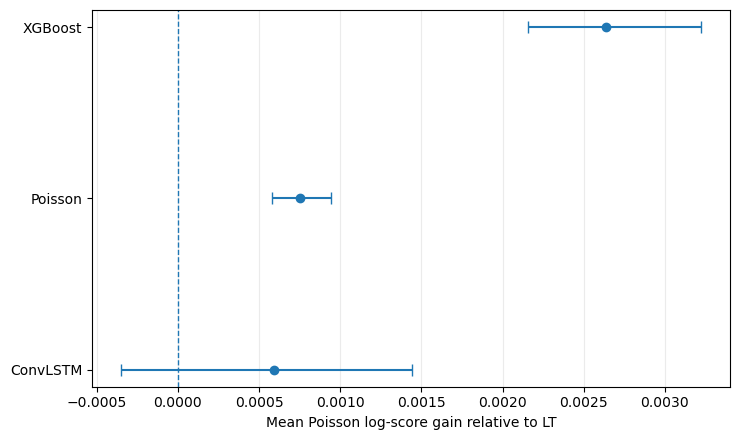

In [47]:
# ============================================================
# 20. Forest plot: test score gain relative to LT
# ============================================================

import matplotlib.pyplot as plt

forest_data = (
    main_results_table[
        main_results_table["model"] != "LT"
    ]
    .copy()
)

# Order from weakest to strongest gain so that
# the strongest model appears at the top.
forest_data = forest_data.sort_values(
    "score_gain_vs_LT",
    ascending=True
).reset_index(drop=True)

models = forest_data["model"].to_numpy()

gains = forest_data[
    "score_gain_vs_LT"
].to_numpy()

lower = forest_data[
    "ci_lower_vs_LT"
].to_numpy()

upper = forest_data[
    "ci_upper_vs_LT"
].to_numpy()

xerr = np.vstack([
    gains - lower,
    upper - gains
])

fig, ax = plt.subplots(
    figsize=(7.5, 4.5)
)

y_pos = np.arange(
    len(models)
)

ax.errorbar(
    gains,
    y_pos,
    xerr=xerr,
    fmt="o",
    capsize=4
)

# Reference: no improvement over LT
ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_yticks(
    y_pos
)

ax.set_yticklabels(
    models
)

ax.set_xlabel(
    "Mean Poisson log-score gain relative to LT"
)

ax.set_ylabel(
    ""
)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "test_score_gain_vs_LT.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "test_score_gain_vs_LT.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# ============================================================
# 21. Compact performance table for the report
# ============================================================

report_performance_table = (
    main_results_table[
        [
            "model",
            "test_log_score",
            "score_gain_vs_LT",
            "ci_lower_vs_LT",
            "ci_upper_vs_LT"
        ]
    ]
    .copy()
)

report_performance_table["95% CI vs LT"] = (
    report_performance_table.apply(
        lambda r:
        "—"
        if r["model"] == "LT"
        else
        f"[{r['ci_lower_vs_LT']:.6f}, "
        f"{r['ci_upper_vs_LT']:.6f}]",
        axis=1
    )
)

report_performance_table = (
    report_performance_table[
        [
            "model",
            "test_log_score",
            "score_gain_vs_LT",
            "95% CI vs LT"
        ]
    ]
)

report_performance_table.columns = [
    "Model",
    "Test log score",
    "Gain vs LT",
    "95% bootstrap CI"
]

report_performance_table

,Model,Test log score,Gain vs LT,95% bootstrap CI
0,XGBoost,-0.027093,0.002636,"[0.002157, 0.003223]"
1,Poisson,-0.028978,0.000751,"[0.000577, 0.000943]"
2,ConvLSTM,-0.029138,0.000591,"[-0.000350, 0.001442]"
3,LT,-0.029729,0.000000,—


In [49]:
if "fig" in globals():
    fig.savefig(
        FIGURE_DIR / "test_score_gain_vs_LT.png",
        dpi=300,
        bbox_inches="tight"
    )